In [1]:
# ==============================================================================
# 0. ENVIRONMENT CHECK
# ==============================================================================
import torch
print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 3060
Using device    : cuda


In [24]:
# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

try:
    from tqdm.auto import tqdm
except ImportError:
    class _NoOpTqdm:
        def __init__(self, iterable, **kwargs):
            self.iterable = iterable
        def __iter__(self):
            return iter(self.iterable)
        def set_postfix(self, *args, **kwargs):
            pass
    def tqdm(iterable, **kwargs):
        return _NoOpTqdm(iterable, **kwargs)

In [25]:
# ==============================================================================
# 2. CONFIGURATION
# ==============================================================================
class Config:
    """Central configuration — update DATA_DIR to your actual path."""
    
    DATA_DIR       = r'D:\dataset'
    
    # Your folders shown in the screenshot
    IMAGE_DIR      = os.path.join(DATA_DIR, 'images')
    MASK_DIR       = os.path.join(DATA_DIR, 'mask')
    METADATA_DIR   = os.path.join(DATA_DIR, 'metadata')

    # If your metadata is a CSV file inside the metadata folder:
    METADATA_CSV   = os.path.join(METADATA_DIR, 'HAM10000_metadata.csv')

    ENCODER_CKPT   = r'D:\Kimi phase 5\encoder\swinunet_v4_encoder.pth'
    CHECKPOINT_DIR = r'D:\Kimi phase 5\checkpoints_phase5'

    # Backward-compatible aliases
    ENCODER_CHECKPOINT = ENCODER_CKPT
    SAVE_DIR = CHECKPOINT_DIR

    # Training
    SEED = 42
    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    NUM_CLASSES = 7

    # Phase 1 (frozen encoder)
    PHASE1_EPOCHS = 10
    PHASE1_LR = 1e-3

    # Phase 2 (unfrozen encoder)
    PHASE2_EPOCHS = 50
    ENCODER_LR = 1e-5
    HEAD_LR = 5e-5

    # Early stopping
    EARLY_STOPPING_PATIENCE = 10

    # V8 Hyperparameters
    FOCAL_GAMMA = 2.0
    LAMBDA_MORPH = 0.2
    NUM_HEADS = 8
    DROPOUT = 0.1

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
# ==============================================================================
# 3. REPRODUCIBILITY
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [27]:
# ==============================================================================
# 4. MORPHOLOGY EXTRACTION (OpenCV — compatible with CV3 & CV4)
# ==============================================================================
def extract_morphology(mask_np):
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    result = cv2.findContours(mask_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = result[0] if len(result) == 2 else result[1]

    if not contours:
        return np.zeros(5, dtype=np.float32)

    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area < 10 or perimeter < 1:
        return np.zeros(5, dtype=np.float32)

    asymmetry = 0.0
    if len(cnt) >= 5:
        try:
            _, axes, _ = cv2.fitEllipse(cnt)
            major = max(axes)
            minor = min(axes)
            if major > 0:
                asymmetry = 1.0 - (minor / major)
        except Exception:
            asymmetry = 0.0

    compactness = (4.0 * np.pi * area) / (perimeter ** 2 + 1e-8)
    border_irregularity = 1.0 - compactness
    color_variance = 0.0
    diameter = np.sqrt(4.0 * area / np.pi) / 224.0

    return np.array([asymmetry, border_irregularity, color_variance,
                     compactness, diameter], dtype=np.float32)


def extract_morphology_with_color(mask_np, image_np):
    features = extract_morphology(mask_np)
    mask_bin = (mask_np > 0.5).astype(np.uint8)
    if mask_bin.sum() > 0:
        masked_pixels = image_np[mask_bin > 0]
        if len(masked_pixels) > 0:
            color_std = np.std(masked_pixels, axis=0).mean()
            features[2] = color_std / 50.0
    return features

In [28]:
# ==============================================================================
# 5. DATASET
# ==============================================================================
class HAM10000Dataset_Morphology(Dataset):
    def __init__(self, df, img_dir, mask_dir, transform=None, mode='train',
                 img_size=224, sex_map=None, site_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.mode = mode
        self.img_size = img_size
        self.sex_map = sex_map or {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
        self.site_to_idx = site_to_idx or {}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        label = int(row['label'])

        img_path = os.path.join(self.img_dir, f"{img_id}.jpg")
        image = np.array(Image.open(img_path).convert("RGB"))

        mask_path = os.path.join(self.mask_dir, f"{img_id}_segmentation.png")
        if not os.path.exists(mask_path):
            mask_path = os.path.join(self.mask_dir, f"{img_id}.png")
        mask = np.array(Image.open(mask_path).convert("L")) / 255.0

        image_resized = cv2.resize(image, (self.img_size, self.img_size))
        mask_resized = cv2.resize(mask.astype(np.float32), (self.img_size, self.img_size))

        morphology = extract_morphology_with_color(mask_resized, image_resized)
        morphology = torch.tensor(morphology, dtype=torch.float32)

        age = row['age'] if not pd.isna(row['age']) else 50.0
        age_norm = age / 100.0
        sex_val = self.sex_map.get(row['sex'], 2.0)
        site_val = self.site_to_idx.get(row['localization'], 0)
        metadata = torch.tensor([age_norm, sex_val, float(site_val)], dtype=torch.float32)

        if self.transform:
            augmented = self.transform(image=image_resized, mask=mask_resized)
            image = augmented['image']
            mask = augmented['mask']
        else:
            image = torch.from_numpy(image_resized.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask_resized).float()

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).float()
        if mask.ndim == 2:
            mask = mask.unsqueeze(0)
        elif mask.ndim == 3 and mask.shape[-1] == 1:
            mask = mask.permute(2, 0, 1)
        elif mask.ndim == 3 and mask.shape[0] != 1:
            mask = mask.unsqueeze(0)

        return {
            'image': image,
            'mask': mask,
            'morphology': morphology,
            'metadata': metadata,
            'label': torch.tensor(label, dtype=torch.long)
        }

In [29]:
# ==============================================================================
# 6. TRANSFORMS (Albumentations >= 1.4 compatible)
# ==============================================================================
def get_transforms(img_size=224, mode='train'):
    if mode == 'train':
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.Rotate(limit=30, p=0.5),
            A.ElasticTransform(alpha=1, sigma=50, p=0.3),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
            A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
            A.GaussianBlur(blur_limit=3, p=0.3),
            A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                            min_holes=1, min_height=1, min_width=1, p=0.3),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2()
        ])

In [30]:
# ==============================================================================
# 7. FPN
# ==============================================================================
class FeaturePyramidNetwork(nn.Module):
    def __init__(self, in_channels_list, out_channels=256):
        super().__init__()
        self.lateral_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for in_ch in in_channels_list
        ])
        self.smooth_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            ) for _ in in_channels_list
        ])

    def forward(self, features):
        laterals = [conv(f) for conv, f in zip(self.lateral_convs, features)]
        for i in range(len(laterals) - 1, 0, -1):
            upsampled = F.interpolate(laterals[i], size=laterals[i-1].shape[2:], mode='nearest')
            laterals[i-1] = laterals[i-1] + upsampled
        return [smooth(lat) for smooth, lat in zip(self.smooth_convs, laterals)]

In [31]:
# ==============================================================================
# 8. MODALITY ENCODERS
# ==============================================================================
class MorphologyEncoder(nn.Module):
    def __init__(self, in_dim=5, out_dim=32):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 16),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(16, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, morphology):
        return self.mlp(morphology)


class MetadataEncoder(nn.Module):
    def __init__(self, num_sites, embed_dim=16, out_dim=32):
        super().__init__()
        self.site_embed = nn.Embedding(num_sites, embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(1 + 1 + embed_dim, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(32, out_dim),
            nn.ReLU(inplace=True)
        )

    def forward(self, metadata):
        age = metadata[:, 0:1]
        sex = metadata[:, 1:2]
        site = metadata[:, 2].long()
        site_vec = self.site_embed(site)
        x = torch.cat([age, sex, site_vec], dim=1)
        return self.mlp(x)

In [32]:
# ==============================================================================
# 9. FiLM GENERATOR
# ==============================================================================
class FiLMGenerator(nn.Module):
    """
    Generate scale (gamma) and shift (beta) from metadata to modulate visual tokens.
    """
    def __init__(self, meta_dim=32, img_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(meta_dim, img_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(img_dim, img_dim * 2)
        )

    def forward(self, meta_feat):
        film = self.mlp(meta_feat)  # (B, 2*img_dim)
        gamma, beta = film.chunk(2, dim=1)  # each (B, img_dim)
        return gamma, beta

In [33]:
# ==============================================================================
# 10. MORPHOLOGY DECODER (Auxiliary Supervision)
# ==============================================================================
class MorphologyDecoder(nn.Module):
    """
    Reconstruct 5-D morphology from PURE attended visual content.
    Forces the attention to actually look at morphology-relevant regions.
    """
    def __init__(self, in_dim=256, out_dim=5):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.mlp(x)

In [34]:
# ==============================================================================
# 11. SPATIAL CROSS-ATTENTION (8 heads)
# ==============================================================================
class SpatialCrossAttentionFusion(nn.Module):
    """
    Returns:
        fused       : (B, img_dim)  — for classification (includes query residual + FFN)
        pure_visual : (B, img_dim)  — for morphology decoder (attention output only)
        attn_weights: (B, N)        — explainability heatmap
    """
    def __init__(self, img_dim=256, morph_dim=32, num_heads=8, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(morph_dim, img_dim)
        self.kv_proj = nn.Linear(img_dim, img_dim)

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=img_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.ffn = nn.Sequential(
            nn.Linear(img_dim, img_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(img_dim * 2, img_dim),
            nn.Dropout(dropout)
        )

        self.norm1 = nn.LayerNorm(img_dim)
        self.norm2 = nn.LayerNorm(img_dim)

    def forward(self, img_tokens, morph_feat):
        B, N, D = img_tokens.shape

        q = self.q_proj(morph_feat).unsqueeze(1)   # (B, 1, D)
        kv = self.kv_proj(img_tokens)              # (B, N, D)

        attn_out, attn_weights = self.cross_attn(q, kv, kv)
        # attn_out: (B, 1, D), attn_weights: (B, 1, N)

        # Pure visual content BEFORE query residual — this is what the decoder sees
        pure_visual = attn_out.squeeze(1)          # (B, D)

        # For classification: add residual + FFN (standard transformer block)
        out = self.norm1(q + attn_out)             # (B, 1, D)
        out = self.norm2(out + self.ffn(out))      # (B, 1, D)
        fused = out.squeeze(1)                     # (B, D)

        return fused, pure_visual, attn_weights.squeeze(1)  # (B,D), (B,D), (B,N)

In [35]:
# ==============================================================================
# 12. LOSS FUNCTIONS
# ==============================================================================
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean'):
        super().__init__()
        if weight is not None:
            self.register_buffer('weight', weight)
        else:
            self.weight = None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, reduction='none', weight=self.weight)
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.reduction == 'mean':
            return focal.mean()
        return focal


class CombinedLoss(nn.Module):
    """
    L_total = FocalLoss(logits, labels) + lambda_morph * MSE(morph_recon, morph_gt)
    """
    def __init__(self, class_weights=None, gamma=2.0, lambda_morph=0.2):
        super().__init__()
        self.focal = FocalLoss(weight=class_weights, gamma=gamma)
        self.lambda_morph = lambda_morph
        self.mse = nn.MSELoss()

    def forward(self, logits, labels, morph_recon, morph_gt):
        loss_cls = self.focal(logits, labels)
        loss_morph = self.lambda_morph * self.mse(morph_recon, morph_gt)
        total = loss_cls + loss_morph
        return total, {
            'loss_total': total.item(),
            'loss_cls': loss_cls.item(),
            'loss_morph': loss_morph.item()
        }

In [36]:
# ==============================================================================
# 13. V8 MODEL
# ==============================================================================
class SkinLesionClassifier_V8(nn.Module):
    def __init__(self, num_classes=7, pretrained=True,
                 encoder_checkpoint="swinunet_v4_encoder.pth",
                 num_sites=15, use_metadata=True):
        super().__init__()
        self.use_metadata = use_metadata

        # Encoder
        self.encoder = timm.create_model(
            'swin_base_patch4_window7_224',
            pretrained=False,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )
        if pretrained and encoder_checkpoint and os.path.exists(encoder_checkpoint):
            ckpt = torch.load(encoder_checkpoint, map_location='cpu', weights_only=False)
            self.encoder.load_state_dict(ckpt, strict=False)
            print(f"Loaded encoder from {encoder_checkpoint}")

        # FPN
        self.fpn = FeaturePyramidNetwork([128, 256, 512, 1024], 256)

        # Modality encoders
        self.morphology_encoder = MorphologyEncoder(in_dim=5, out_dim=32)
        if use_metadata:
            self.metadata_encoder = MetadataEncoder(num_sites=num_sites, embed_dim=16, out_dim=32)
            self.film_generator = FiLMGenerator(meta_dim=32, img_dim=256)
        else:
            self.metadata_encoder = None
            self.film_generator = None

        # V8 core
        self.morphology_decoder = MorphologyDecoder(in_dim=256, out_dim=5)
        self.spatial_fusion = SpatialCrossAttentionFusion(
            img_dim=256, morph_dim=32, num_heads=8, dropout=0.1
        )

        # Classifier
        clf_in = 256 + 32 + (32 if use_metadata else 0)
        self.classifier = nn.Sequential(
            nn.Linear(clf_in, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def _to_channels_first(self, features):
        expected = [128, 256, 512, 1024]
        out = []
        for i, f in enumerate(features):
            if f.ndim == 4 and f.shape[-1] == expected[i]:
                f = f.permute(0, 3, 1, 2).contiguous()
            out.append(f)
        return out

    def _masked_pool_tokens(self, feat_map, mask):
        B, C, H, W = feat_map.shape
        mask_r = F.interpolate(mask, size=(H, W), mode='nearest')
        tokens = feat_map.view(B, C, H * W).permute(0, 2, 1)   # (B, HW, C)
        mask_flat = mask_r.view(B, H * W)                      # (B, HW)

        empty = (mask_flat.sum(dim=1, keepdim=True) < 1e-6).float()
        mask_flat = mask_flat + empty
        tokens = tokens * mask_flat.unsqueeze(-1)
        return tokens, mask_flat

    def forward(self, image, mask, morphology, metadata=None):
        # Image encoding
        features = self._to_channels_first(self.encoder(image))
        fpn_features = self.fpn(features)
        p4 = fpn_features[2]  # (B, 256, 14, 14)

        # Masked pooling → 196 tokens
        img_tokens, _ = self._masked_pool_tokens(p4, mask)  # (B, 196, 256)

        # Encode modalities
        morph_feat = self.morphology_encoder(morphology)  # (B, 32)
        meta_feat = None
        if self.use_metadata and metadata is not None:
            meta_feat = self.metadata_encoder(metadata)       # (B, 32)
            gamma, beta = self.film_generator(meta_feat)      # each (B, 256)
            img_tokens = img_tokens * (1 + gamma.unsqueeze(1)) + beta.unsqueeze(1)

        # Spatial cross-attention
        # fused       → goes to classifier (includes query residual)
        # pure_visual → goes to morphology decoder (attention output only)
        fused, pure_visual, attn_weights = self.spatial_fusion(img_tokens, morph_feat)

        # Auxiliary morphology reconstruction (supervision on PURE visual content)
        morph_recon = self.morphology_decoder(pure_visual)  # (B, 5)

        # Concatenate all modalities for classification
        concat = [fused, morph_feat]
        if meta_feat is not None:
            concat.append(meta_feat)
        fused_vec = torch.cat(concat, dim=1)

        logits = self.classifier(fused_vec)
        return logits, attn_weights, morph_recon

In [37]:
# ==============================================================================
# 14. CLASS WEIGHTS (train split only)
# ==============================================================================
def get_class_weights(df):
    counts = df['label'].value_counts().sort_index().values
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float32)

In [38]:
# ==============================================================================
# 15. TRAINER
# ==============================================================================
class Trainer:
    def __init__(self, model, config, save_dir):
        self.model = model.to(config.DEVICE)
        self.config = config
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

        self.history = {
            'phase': [], 'epoch': [],
            'train_loss': [], 'val_loss': [],
            'train_acc': [], 'val_acc': [],
            'train_f1': [], 'val_f1': []
        }

    def _get_optimizer(self, phase='phase1'):
        if phase == 'phase1':
            for p in self.model.encoder.parameters():
                p.requires_grad = False

            params = [
                {'params': self.model.fpn.parameters()},
                {'params': self.model.morphology_encoder.parameters()},
                {'params': self.model.morphology_decoder.parameters()},
                {'params': self.model.spatial_fusion.parameters()},
                {'params': self.model.classifier.parameters()}
            ]
            if self.model.metadata_encoder is not None:
                params.append({'params': self.model.metadata_encoder.parameters()})
                params.append({'params': self.model.film_generator.parameters()})
            return torch.optim.AdamW(params, lr=self.config.PHASE1_LR, weight_decay=1e-4)

        if phase == 'phase2':
            for p in self.model.encoder.parameters():
                p.requires_grad = True

            params = [
                {'params': self.model.encoder.parameters(), 'lr': self.config.ENCODER_LR},
                {'params': self.model.fpn.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_encoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.morphology_decoder.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.spatial_fusion.parameters(), 'lr': self.config.HEAD_LR},
                {'params': self.model.classifier.parameters(), 'lr': self.config.HEAD_LR}
            ]
            if self.model.metadata_encoder is not None:
                params.append({'params': self.model.metadata_encoder.parameters(), 'lr': self.config.HEAD_LR})
                params.append({'params': self.model.film_generator.parameters(), 'lr': self.config.HEAD_LR})
            return torch.optim.AdamW(params, weight_decay=1e-4)

        raise ValueError("phase must be 'phase1' or 'phase2'")

    def _num_epochs(self, phase):
        return self.config.PHASE1_EPOCHS if phase == 'phase1' else self.config.PHASE2_EPOCHS

    def _phase_name(self, phase):
        return 'PHASE 1: Frozen encoder' if phase == 'phase1' else 'PHASE 2: Unfrozen encoder'

    def _checkpoint_path(self, phase):
        return os.path.join(self.save_dir, f'{phase}_latest.pth')

    def _best_model_path(self):
        return os.path.join(self.save_dir, 'best_model.pth')

    def _load_best_score(self):
        path = self._best_model_path()
        if not os.path.exists(path):
            return 0.0
        ckpt = torch.load(path, map_location=self.config.DEVICE, weights_only=False)
        return ckpt.get('best_val_f1', ckpt.get('val_f1', 0.0))

    def _save_checkpoint(self, phase, epoch, optimizer, scheduler, best_val_f1, patience_counter):
        ckpt = {
            'phase': phase,
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'history': self.history,
            'best_val_f1': best_val_f1,
            'patience_counter': patience_counter,
        }
        torch.save(ckpt, self._checkpoint_path(phase))

    def _resume_phase(self, phase, optimizer, scheduler, resume=True):
        best_val_f1 = self._load_best_score()
        patience_counter = 0
        start_epoch = 0

        if not resume:
            return start_epoch, best_val_f1, patience_counter

        ckpt_path = self._checkpoint_path(phase)
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            if scheduler is not None and ckpt.get('scheduler_state_dict') is not None:
                scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', best_val_f1)
            patience_counter = ckpt.get('patience_counter', 0)
            start_epoch = ckpt['epoch'] + 1
            print(f"Resuming {phase} from epoch {start_epoch + 1}")
            return start_epoch, best_val_f1, patience_counter

        best_path = self._best_model_path()
        if phase == 'phase2' and os.path.exists(best_path):
            ckpt = torch.load(best_path, map_location=self.config.DEVICE, weights_only=False)
            self.model.load_state_dict(ckpt['model_state_dict'])
            self.history = ckpt.get('history', self.history)
            best_val_f1 = ckpt.get('best_val_f1', ckpt.get('val_f1', best_val_f1))
            print(f"Loaded best model before phase2 (val F1: {best_val_f1:.4f})")

        return start_epoch, best_val_f1, patience_counter

    def train_epoch(self, loader, criterion, optimizer, scheduler, epoch, total_epochs, phase):
        self.model.train()
        total_loss = 0
        all_preds, all_labels = [], []

        progress = tqdm(loader, desc=f"{phase} epoch {epoch + 1}/{total_epochs}", leave=False)
        for batch_idx, batch in enumerate(progress):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            morphology = batch['morphology'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)

            optimizer.zero_grad()
            logits, _, morph_recon = self.model(images, masks, morphology, metadata)
            loss, loss_dict = criterion(logits, labels, morph_recon, morphology)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            progress.set_postfix({
                'loss': f"{total_loss / (batch_idx + 1):.4f}",
                'morph': f"{loss_dict['loss_morph']:.4f}"
            })

        if scheduler is not None:
            scheduler.step()

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        return total_loss / len(loader), acc, f1

    @torch.no_grad()
    def evaluate(self, loader, criterion, desc='Validation'):
        self.model.eval()
        total_loss = 0
        all_preds, all_labels, all_probs, attn_stats = [], [], [], []

        for batch in tqdm(loader, desc=desc, leave=False):
            images = batch['image'].to(self.config.DEVICE)
            masks = batch['mask'].to(self.config.DEVICE)
            morphology = batch['morphology'].to(self.config.DEVICE)
            labels = batch['label'].to(self.config.DEVICE)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(self.config.DEVICE)

            logits, attn_weights, morph_recon = self.model(images, masks, morphology, metadata)
            loss, _ = criterion(logits, labels, morph_recon, morphology)
            total_loss += loss.item()

            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            attn_stats.append(attn_weights.mean().item())

        acc = accuracy_score(all_labels, all_preds)
        f1 = f1_score(all_labels, all_preds, average='macro')
        try:
            auc = roc_auc_score(
                np.eye(self.config.NUM_CLASSES)[all_labels],
                np.array(all_probs),
                average='macro', multi_class='ovr'
            )
        except Exception:
            auc = 0.0

        return total_loss / len(loader), acc, f1, auc, np.mean(attn_stats)

    def fit_phase(self, phase, train_loader, val_loader, class_weights, resume=True):
        if phase not in {'phase1', 'phase2'}:
            raise ValueError("phase must be 'phase1' or 'phase2'")

        total_epochs = self._num_epochs(phase)
        criterion = CombinedLoss(
            class_weights=class_weights.to(self.config.DEVICE),
            gamma=self.config.FOCAL_GAMMA,
            lambda_morph=self.config.LAMBDA_MORPH
        )
        optimizer = self._get_optimizer(phase)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

        start_epoch, best_val_f1, patience_counter = self._resume_phase(phase, optimizer, scheduler, resume)

        print("\n" + "="*60)
        print(self._phase_name(phase))
        print("="*60)

        if start_epoch >= total_epochs:
            print(f"{phase} already complete.")
            print(f"Best validation F1: {best_val_f1:.4f}")
            return

        epoch_progress = tqdm(range(start_epoch, total_epochs), desc=f"{phase} epochs",
                              total=total_epochs, initial=start_epoch)
        for epoch in epoch_progress:
            train_loss, train_acc, train_f1 = self.train_epoch(
                train_loader, criterion, optimizer, scheduler, epoch, total_epochs, phase)
            val_loss, val_acc, val_f1, val_auc, avg_attn = self.evaluate(
                val_loader, criterion, desc=f"{phase} validation {epoch + 1}/{total_epochs}")

            epoch_progress.set_postfix({
                'train_loss': f"{train_loss:.4f}",
                'train_f1': f"{train_f1:.4f}",
                'val_loss': f"{val_loss:.4f}",
                'val_f1': f"{val_f1:.4f}",
                'best_f1': f"{max(best_val_f1, val_f1):.4f}"
            })

            print(f"Epoch {epoch+1}/{total_epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} F1: {train_f1:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f} AUC: {val_auc:.4f} | "
                  f"Avg Attn: {avg_attn:.4f}")

            for k, v in zip(['phase', 'epoch', 'train_loss', 'val_loss',
                             'train_acc', 'val_acc', 'train_f1', 'val_f1'],
                            [phase, epoch + 1, train_loss, val_loss,
                             train_acc, val_acc, train_f1, val_f1]):
                self.history[k].append(v)

            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save({
                    'phase': phase, 'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
                    'history': self.history,
                    'val_f1': val_f1, 'best_val_f1': best_val_f1,
                }, self._best_model_path())
                print(f"  -> Saved best model (val F1: {val_f1:.4f})")
            else:
                patience_counter += 1

            self._save_checkpoint(phase, epoch, optimizer, scheduler, best_val_f1, patience_counter)
            print(f"  -> Saved checkpoint: {self._checkpoint_path(phase)}")

            if phase == 'phase2' and patience_counter >= self.config.EARLY_STOPPING_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"\nBest validation F1: {best_val_f1:.4f}")

    def fit(self, train_loader, val_loader, class_weights, resume=True):
        self.fit_phase('phase1', train_loader, val_loader, class_weights, resume=resume)
        self.fit_phase('phase2', train_loader, val_loader, class_weights, resume=resume)

    def plot_history(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        axes[0].plot(self.history['train_loss'], label='Train')
        axes[0].plot(self.history['val_loss'], label='Val')
        axes[0].set_title('Loss'); axes[0].legend()

        axes[1].plot(self.history['train_acc'], label='Train')
        axes[1].plot(self.history['val_acc'], label='Val')
        axes[1].set_title('Accuracy'); axes[1].legend()

        axes[2].plot(self.history['train_f1'], label='Train')
        axes[2].plot(self.history['val_f1'], label='Val')
        axes[2].set_title('Macro F1'); axes[2].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(self.save_dir, 'training_curves.png'))
        plt.show()

In [39]:
# ==============================================================================
# 16. EVALUATION
# ==============================================================================
def evaluate_model(model, test_loader, config, save_dir):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            images = batch['image'].to(config.DEVICE)
            masks = batch['mask'].to(config.DEVICE)
            morphology = batch['morphology'].to(config.DEVICE)
            labels = batch['label'].to(config.DEVICE)
            metadata = batch.get('metadata')
            if metadata is not None:
                metadata = metadata.to(config.DEVICE)

            logits, _, _ = model(images, masks, morphology, metadata)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    try:
        auc_macro = roc_auc_score(
            np.eye(config.NUM_CLASSES)[all_labels],
            np.array(all_probs),
            average='macro', multi_class='ovr'
        )
    except Exception:
        auc_macro = 0.0

    report = classification_report(
        all_labels, all_preds,
        target_names=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
        output_dict=True
    )

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'],
                yticklabels=['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'])
    plt.title('Confusion Matrix - V8')
    plt.ylabel('True'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'confusion_matrix.png'))
    plt.show()

    print("\n" + "="*60)
    print("V8 TEST RESULTS - Morphology-Supervised Attention + Metadata FiLM")
    print("="*60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Weighted F1: {f1_weighted:.4f}")
    print(f"Macro AUC: {auc_macro:.4f}")
    print("\nPer-class metrics:")
    for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
        print(f"  {cls:6s}: Precision={report[cls]['precision']:.4f}, "
              f"Recall={report[cls]['recall']:.4f}, F1={report[cls]['f1-score']:.4f}")

    print(f"\nTarget (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733")
    if f1_macro > 0.733:
        print("SUCCESS: Beat V4-C baseline!")
    else:
        print("NEEDS IMPROVEMENT")

    return {
        'accuracy': acc, 'macro_f1': f1_macro, 'weighted_f1': f1_weighted,
        'macro_auc': auc_macro, 'per_class': report, 'confusion_matrix': cm
    }

In [40]:
# ==============================================================================
# 17. ATTENTION VISUALIZATION (Explainability)
# ==============================================================================
def save_attention_visualizations(batch, model, config, save_dir, num_samples=4):
    model.eval()
    num_samples = min(num_samples, len(batch['image']))
    images = batch['image'][:num_samples].to(config.DEVICE)
    masks = batch['mask'][:num_samples].to(config.DEVICE)
    morphology = batch['morphology'][:num_samples].to(config.DEVICE)
    metadata = batch.get('metadata')
    if metadata is not None:
        metadata = metadata[:num_samples].to(config.DEVICE)

    with torch.no_grad():
        _, attn_weights, morph_recon = model(images, masks, morphology, metadata)
        attn_maps = attn_weights.view(num_samples, 14, 14).cpu().numpy()
        morph_recon_np = morph_recon.cpu().numpy()
        morph_gt_np = morphology[:num_samples].cpu().numpy()

    images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    images_np = images_np * std + mean
    images_np = np.clip(images_np, 0, 1)
    masks_np = masks.cpu().squeeze(1).numpy()

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = np.reshape(axes, (1, -1))

    for i in range(num_samples):
        axes[i, 0].imshow(images_np[i])
        axes[i, 0].set_title('Original Image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(images_np[i])
        axes[i, 1].imshow(masks_np[i], alpha=0.5, cmap='jet')
        mse_val = np.mean((morph_recon_np[i] - morph_gt_np[i]) ** 2)
        axes[i, 1].set_title(f'Mask | Morph MSE: {mse_val:.3f}')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(images_np[i])
        attn_up = cv2.resize(attn_maps[i], (config.IMG_SIZE, config.IMG_SIZE))
        axes[i, 2].imshow(attn_up, alpha=0.6, cmap='hot')
        axes[i, 2].set_title('Morphology Attention (14x14)')
        axes[i, 2].axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, 'attention_visualization.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved attention visualizations to {save_path}")

In [41]:
# ==============================================================================
# 18. PREPARE TRAINING
# ==============================================================================
def prepare_training():
    config = Config()
    set_seed(config.SEED)

    print("="*60)
    print("SkinLesionClassifier V8 - Morphology-Supervised Attention + FiLM")
    print("="*60)
    print(f"Device: {config.DEVICE}")

    print("\n[1/5] Loading data...")
    df = pd.read_csv(config.METADATA_CSV)

    dx_to_idx = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
    df['label'] = df['dx'].map(dx_to_idx)

    print(f"Dataset size: {len(df)}")
    print(f"Class distribution: {df['dx'].value_counts().to_dict()}")

    print("\n[2/5] Splitting dataset...")
    train_df, temp_df = train_test_split(
        df, test_size=0.3, stratify=df['label'], random_state=config.SEED)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df['label'], random_state=config.SEED)
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

    sex_map = {'male': 0.0, 'female': 1.0, 'unknown': 2.0}
    all_sites = sorted(df['localization'].unique())
    site_to_idx = {s: i for i, s in enumerate(all_sites)}
    num_sites = len(all_sites)
    print(f"Localization sites found: {num_sites}")

    class_weights = get_class_weights(train_df)

    print("\n[3/5] Creating datasets...")
    train_dataset = HAM10000Dataset_Morphology(
        train_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'train'),
        mode='train', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)
    val_dataset = HAM10000Dataset_Morphology(
        val_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='val', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)
    test_dataset = HAM10000Dataset_Morphology(
        test_df, config.IMAGE_DIR, config.MASK_DIR,
        transform=get_transforms(config.IMG_SIZE, 'val'),
        mode='test', img_size=config.IMG_SIZE,
        sex_map=sex_map, site_to_idx=site_to_idx)

    print("\n[4/5] Creating data loaders...")
    sampler = WeightedRandomSampler(
        weights=class_weights[train_df['label'].values].tolist(),
        num_samples=len(train_df), replacement=True)

    train_loader = DataLoader(
        train_dataset, batch_size=config.BATCH_SIZE, sampler=sampler,
        num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(
        val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(
        test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
        num_workers=config.NUM_WORKERS, pin_memory=True)

    print("\n[5/5] Initializing V8 model...")
    model = SkinLesionClassifier_V8(
        num_classes=config.NUM_CLASSES,
        pretrained=True,
        encoder_checkpoint=config.ENCODER_CHECKPOINT,
        num_sites=num_sites,
        use_metadata=True
    )

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    return config, class_weights, train_loader, val_loader, test_loader, model

In [42]:
# ==============================================================================
# 19. FINAL EVALUATION WRAPPER
# ==============================================================================
def run_final_evaluation(model, test_loader, config, save_dir):
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)

    ckpt_path = os.path.join(save_dir, 'best_model.pth')
    ckpt = torch.load(ckpt_path, map_location=config.DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    results = evaluate_model(model, test_loader, config, save_dir)

    print("\nGenerating attention visualizations...")
    first_batch = next(iter(test_loader))
    save_attention_visualizations(first_batch, model, config, save_dir, num_samples=4)

    print(f"\nResults saved to: {save_dir}")
    return results


def main():
    config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
    trainer = Trainer(model, config, config.SAVE_DIR)
    trainer.fit(train_loader, val_loader, class_weights, resume=True)
    trainer.plot_history()
    return run_final_evaluation(model, test_loader, config, config.SAVE_DIR)

In [43]:
# ==============================================================================
# 20. NOTEBOOK EXECUTION CELLS
# ==============================================================================
# Setup:
config, class_weights, train_loader, val_loader, test_loader, model = prepare_training()
trainer = Trainer(model, config, config.SAVE_DIR)

SkinLesionClassifier V8 - Morphology-Supervised Attention + FiLM
Device: cuda

[1/5] Loading data...
Dataset size: 10015
Class distribution: {'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}

[2/5] Splitting dataset...
Train: 7010 | Val: 1502 | Test: 1503
Localization sites found: 15

[3/5] Creating datasets...

[4/5] Creating data loaders...

[5/5] Initializing V8 model...


C:\Users\user\AppData\Local\Temp\ipykernel_15772\2061767605.py:16: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32,


Loaded encoder from D:\Kimi phase 5\encoder\swinunet_v4_encoder.pth
Total parameters: 90,472,756
Trainable parameters: 90,472,756


In [45]:
import torch

paths = [
    r'D:\Kimi phase 5\checkpoints_phase5\phase1_latest.pth',
    r'D:\Kimi phase 5\checkpoints_phase5\best_model.pth'
]

for p in paths:
    print(f"\nTesting: {p}")
    try:
        ckpt = torch.load(p, map_location='cpu')
        print("SUCCESS")
        print(type(ckpt))

        if isinstance(ckpt, dict):
            print("Keys:", ckpt.keys())

    except Exception as e:
        print("FAILED")
        print(e)


Testing: D:\Kimi phase 5\checkpoints_phase5\phase1_latest.pth
FAILED
PytorchStreamReader failed reading zip archive: failed finding central directory

Testing: D:\Kimi phase 5\checkpoints_phase5\best_model.pth
SUCCESS
<class 'dict'>
Keys: dict_keys(['phase', 'epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'history', 'val_f1', 'best_val_f1'])


C:\Users\user\AppData\Local\Temp\ipykernel_15772\2605000519.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(p, map_location='cpu')


In [46]:
# Phase 1:
trainer.fit_phase('phase1', train_loader, val_loader, class_weights, resume=True)


PHASE 1: Frozen encoder


phase1 epochs:   0%|          | 0/10 [00:00<?, ?it/s]

phase1 epoch 1/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 1/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.6453 Acc: 0.1874 F1: 0.1934 | Val Loss: 0.2885 Acc: 0.1245 F1: 0.1114 AUC: 0.7557 | Avg Attn: 0.0051
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase1_latest.pth


...

phase1 validation 9/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.3122 Acc: 0.3789 F1: 0.4205 | Val Loss: 0.1713 Acc: 0.2057 F1: 0.2583 AUC: 0.8466 | Avg Attn: 0.0051
  -> Saved best model (val F1: 0.2583)
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase1_latest.pth


phase1 epoch 10/10:   0%|          | 0/220 [00:00<?, ?it/s]

phase1 validation 10/10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2989 Acc: 0.3783 F1: 0.4180 | Val Loss: 0.1670 Acc: 0.2064 F1: 0.2723 AUC: 0.8503 | Avg Attn: 0.0051
  -> Saved best model (val F1: 0.2723)
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase1_latest.pth

Best validation F1: 0.2723


In [47]:
# Phase 2:
trainer.fit_phase('phase2', train_loader, val_loader, class_weights, resume=True)

Loaded best model before phase2 (val F1: 0.2723)

PHASE 2: Unfrozen encoder


phase2 epochs:   0%|          | 0/50 [00:00<?, ?it/s]

phase2 epoch 1/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 1/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 0.3211 Acc: 0.3682 F1: 0.4068 | Val Loss: 0.1855 Acc: 0.1997 F1: 0.2564 AUC: 0.8380 | Avg Attn: 0.0051
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase2_latest.pth


...

phase2 validation 31/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 31/50 | Train Loss: 0.2258 Acc: 0.4676 F1: 0.5300 | Val Loss: 0.1426 Acc: 0.3129 F1: 0.3727 AUC: 0.8787 | Avg Attn: 0.0051
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase2_latest.pth


phase2 epoch 32/50:   0%|          | 0/220 [00:00<?, ?it/s]

phase2 validation 32/50:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 32/50 | Train Loss: 0.2541 Acc: 0.4757 F1: 0.5368 | Val Loss: 0.1397 Acc: 0.3688 F1: 0.3951 AUC: 0.8888 | Avg Attn: 0.0051
  -> Saved checkpoint: D:\Kimi phase 5\checkpoints_phase5\phase2_latest.pth

Early stopping at epoch 32

Best validation F1: 0.4037


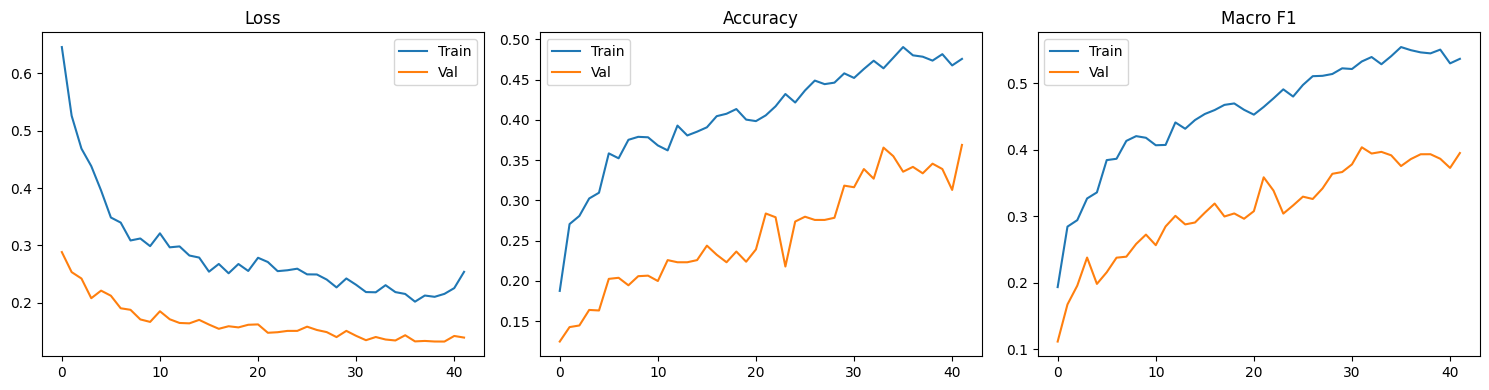


FINAL EVALUATION


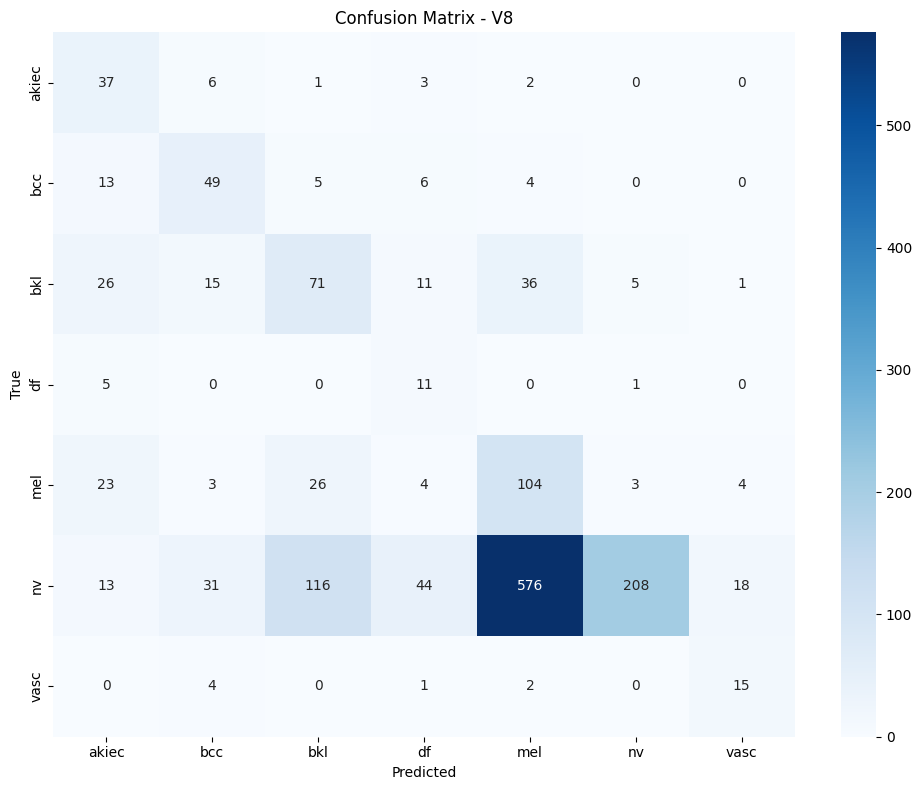


V8 TEST RESULTS - Morphology-Supervised Attention + Metadata FiLM
Accuracy: 0.3293
Macro F1: 0.3780
Weighted F1: 0.3458
Macro AUC: 0.8648

Per-class metrics:
  akiec : Precision=0.3162, Recall=0.7551, F1=0.4458
  bcc   : Precision=0.4537, Recall=0.6364, F1=0.5297
  bkl   : Precision=0.3242, Recall=0.4303, F1=0.3698
  df    : Precision=0.1375, Recall=0.6471, F1=0.2268
  mel   : Precision=0.1436, Recall=0.6228, F1=0.2334
  nv    : Precision=0.9585, Recall=0.2068, F1=0.3401
  vasc  : Precision=0.3947, Recall=0.6818, F1=0.5000

Target (beat V4-C): Accuracy >= 0.835, Macro F1 >= 0.733
NEEDS IMPROVEMENT

Generating attention visualizations...
Saved attention visualizations to D:\Kimi phase 5\checkpoints_phase5\attention_visualization.png

Results saved to: D:\Kimi phase 5\checkpoints_phase5


In [48]:
# Plot + Test:
trainer.plot_history()
results = run_final_evaluation(model, test_loader, config, config.SAVE_DIR)